<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/Principle%20Component%20Analysis(PCA)%20/pca_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [45]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [46]:
import plotly.express as px

fig = px.scatter_3d(df, x='feature1', y='feature2', z='feature3',
              color='target')
fig.show()

In [47]:
#step1-apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [48]:
#step2- find covariance matrix
covariance_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [49]:
#step3- finding eigen values and eigen vector
eigen_values,eigen_vectors=np.linalg.eig(covariance_matrix)

In [50]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [51]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

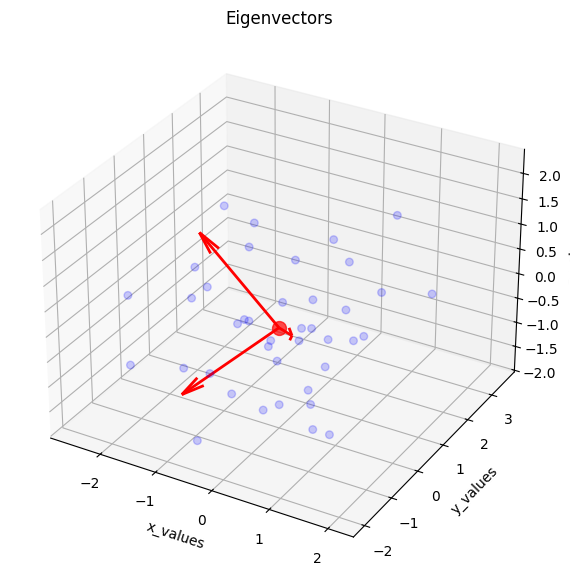

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of data
ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           c='blue', alpha=0.2, s=30)

# Mean of data
mean = [df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()]
ax.scatter(*mean, c='red', s=100, alpha=0.7)

# Plot eigenvectors
for v in eigen_vectors.T:   # columns are eigenvectors
    ax.quiver(*mean, *v, length=2, color='r', arrow_length_ratio=0.2, linewidth=2)

# Labels
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
ax.set_title('Eigenvectors')

plt.show()
plt.show()

In [53]:
pc=eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [54]:
transformed_df=np.dot(df.iloc[:,0:3],pc.T)
new_df=pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target']=df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [58]:
fig = px.scatter(new_df, x='PC1', y='PC2', color='target')
fig.update_traces(marker=dict(size=12))  # increase dot size (default ~6)
fig.show()